# SentinelX Notebook 3: Feature Engineering

## Stage 2: Creating Predictive Features

Raw sensor values alone aren't enough for ML. We need to create **features** that capture:
- **Trends**: Is temperature rising or stable?
- **Variability**: Is vibration erratic or smooth?
- **History**: What happened in the last hour?
- **Cross-domain patterns**: High errors + high temperature = problem?

### Feature Types We Create:
1. **Rolling Statistics**: Mean, std over time windows (6, 12, 36 periods)
2. **Lag Features**: Values from T-1, T-2, T-6 (capture recent history)
3. **Cross-Domain Features**: Combine hardware + software signals

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [10]:
# Load the Parquet data (output from Stage 1)
sys_df = pd.read_parquet('../data/parquet/system_metrics.parquet')
print(f"System Metrics: {sys_df.shape[0]:,} rows × {sys_df.shape[1]} columns")
sys_df.head()

System Metrics: 50,000 rows × 20 columns


,timestamp,machine_id,product_type,air_temperature_K,process_temperature_K,rotational_speed_rpm,torque_Nm,tool_wear_min,vibration_mm_s,pressure_psi,network_latency_ms,edge_processing_time_ms,fuzzy_pid_output,machine_failure,failure_TWF,failure_HDF,failure_PWF,failure_OSF,failure_RNF,maintenance_status
0,2024-01-01 00:00:00,M1,L,300.42,309.79,1441.0,54.48,2.6,20.395,112.96,8.607,5.743,0.8468,0,0,0,0,0,0,Normal
1,2024-01-01 00:05:00,M2,H,301.31,311.26,1424.7,47.85,2.6,19.789,106.46,8.361,5.596,0.8797,0,0,0,0,0,0,Normal
2,2024-01-01 00:10:00,M3,M,300.04,310.73,1640.6,49.78,1.0,17.637,109.73,9.246,6.035,0.9027,0,0,0,0,0,0,Normal
3,2024-01-01 00:15:00,M4,L,299.03,308.53,1263.7,56.08,2.3,14.856,110.42,13.281,10.445,0.8824,0,0,0,0,0,0,Normal
4,2024-01-01 00:20:00,M5,L,300.89,309.48,1394.3,51.25,1.5,19.512,112.86,9.938,9.571,0.9330,0,0,0,0,0,0,Normal


## 1. Rolling Window Features

### What is a Rolling Window?

A rolling window looks at the **past N observations** to compute statistics.

```
Time:     T1  T2  T3  T4  T5  T6  T7  T8  T9  T10
Values:   10  12  11  15  14  13  18  20  19  22
                              ↑
                    Window of 3 at T6: [15, 14, 13]
                    Rolling Mean = (15+14+13)/3 = 14
                    Rolling Std = measure of variability
```

### Why Multiple Windows?
- **Short window (6 periods = 30 min)**: Captures recent spikes
- **Medium window (12 periods = 1 hour)**: Smoothed trends
- **Long window (36 periods = 3 hours)**: Long-term baseline

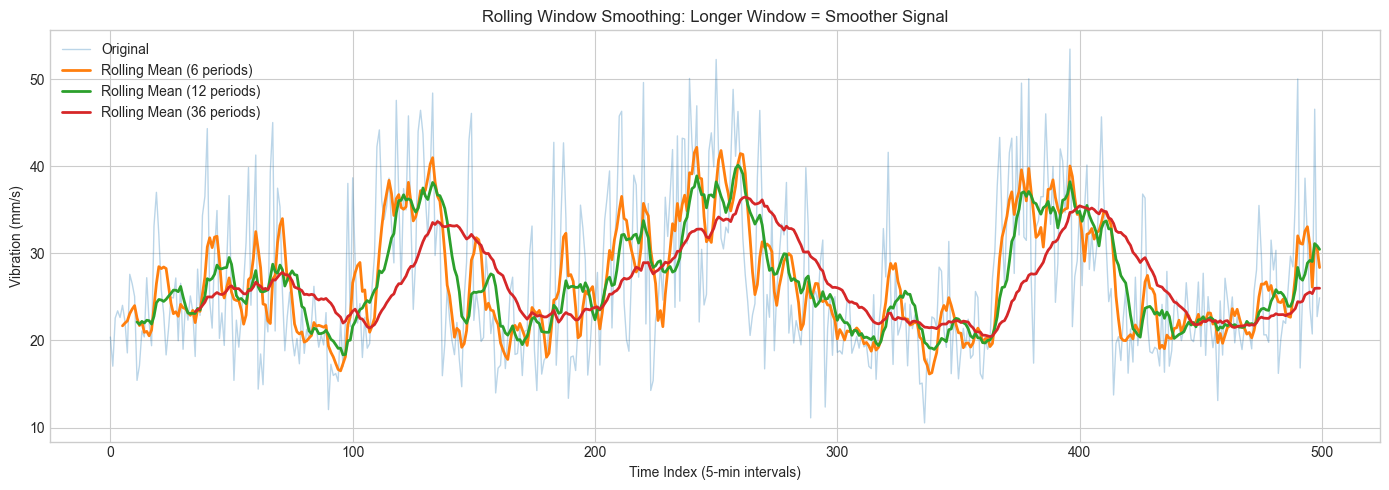

In [11]:
# Demo: Rolling features for one machine
m1 = sys_df[sys_df['machine_id'] == 'M1'].copy()
m1 = m1.sort_values('timestamp').reset_index(drop=True)

# Original vibration
original = m1['vibration_mm_s'].values

# Rolling mean with different windows
roll_6 = m1['vibration_mm_s'].rolling(window=6).mean()
roll_12 = m1['vibration_mm_s'].rolling(window=12).mean()
roll_36 = m1['vibration_mm_s'].rolling(window=36).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Only show first 500 points for clarity
n = 500
ax.plot(range(n), original[:n], alpha=0.3, label='Original', linewidth=1)
ax.plot(range(n), roll_6[:n], label='Rolling Mean (6 periods)', linewidth=2)
ax.plot(range(n), roll_12[:n], label='Rolling Mean (12 periods)', linewidth=2)
ax.plot(range(n), roll_36[:n], label='Rolling Mean (36 periods)', linewidth=2)

ax.set_xlabel('Time Index (5-min intervals)')
ax.set_ylabel('Vibration (mm/s)')
ax.set_title('Rolling Window Smoothing: Longer Window = Smoother Signal')
ax.legend()
plt.tight_layout()
plt.show()

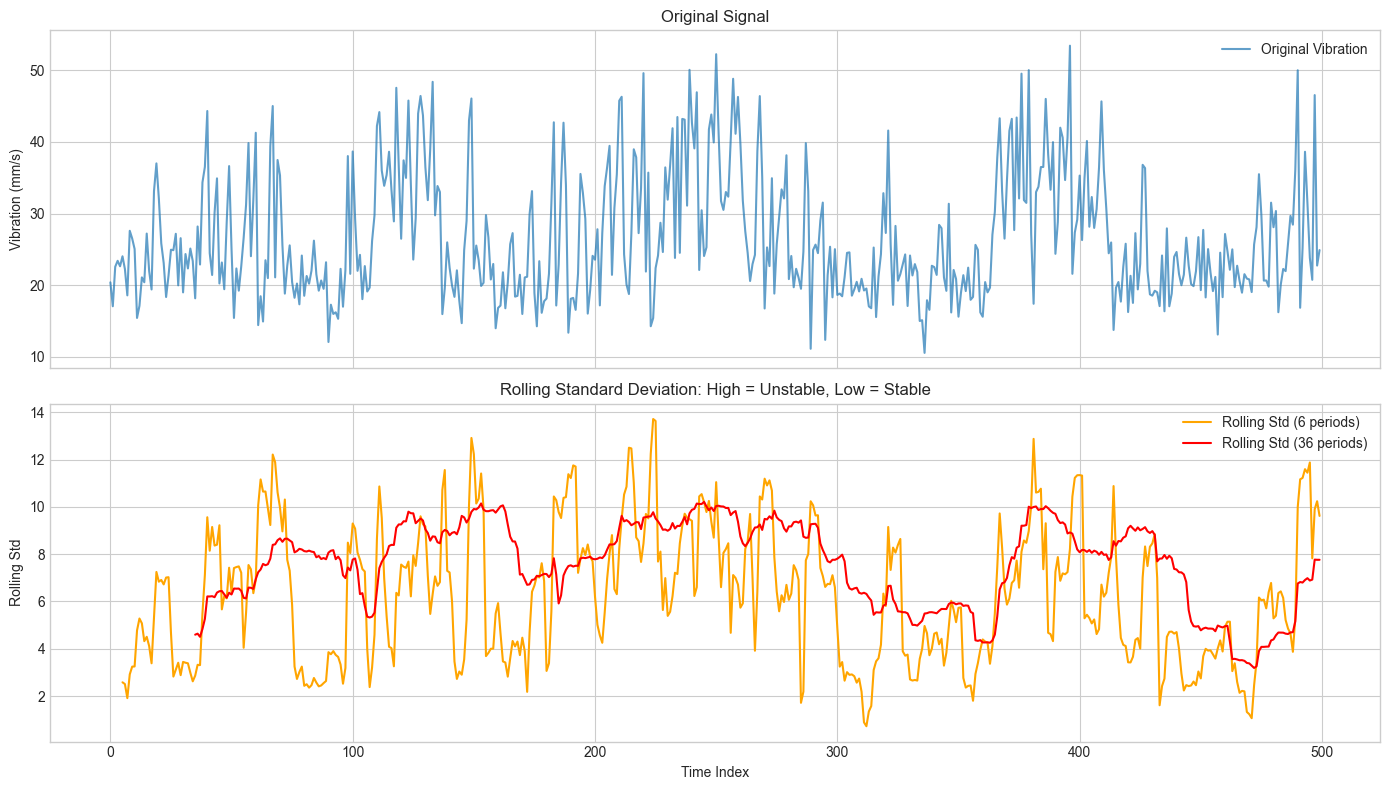

In [12]:
# Rolling Standard Deviation: Captures volatility
roll_std_6 = m1['vibration_mm_s'].rolling(window=6).std()
roll_std_36 = m1['vibration_mm_s'].rolling(window=36).std()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

n = 500
axes[0].plot(range(n), original[:n], label='Original Vibration', alpha=0.7)
axes[0].set_ylabel('Vibration (mm/s)')
axes[0].set_title('Original Signal')
axes[0].legend()

axes[1].plot(range(n), roll_std_6[:n], label='Rolling Std (6 periods)', color='orange')
axes[1].plot(range(n), roll_std_36[:n], label='Rolling Std (36 periods)', color='red')
axes[1].set_ylabel('Rolling Std')
axes[1].set_xlabel('Time Index')
axes[1].set_title('Rolling Standard Deviation: High = Unstable, Low = Stable')
axes[1].legend()

plt.tight_layout()
plt.show()

### Rolling Features We Create:

For each of these columns:
- `air_temperature_K`, `process_temperature_K`, `rotational_speed_rpm`
- `torque_Nm`, `tool_wear_min`, `vibration_mm_s`, `pressure_psi`
- `cpu_utilization_pct`, `memory_utilization_pct`, `disk_io_wait_ms`
- `network_latency_ms`, `error_rate_pct`

We compute:
- Mean over 6, 12, 36 periods → 12 cols × 3 windows = 36 features
- Std over 6, 12, 36 periods → 12 cols × 3 windows = 36 features

**Total: 72+ rolling features**

## 2. Lag Features

### What is a Lag?

A lag feature is simply "the value N steps ago":

```
Time:        T1    T2    T3    T4    T5    T6
Vibration:   1.2   1.5   1.8   2.0   2.3   2.1
Lag_1:       NaN   1.2   1.5   1.8   2.0   2.3  ← value from 1 step ago
Lag_2:       NaN   NaN   1.2   1.5   1.8   2.0  ← value from 2 steps ago
```

### Why Lags Matter:
- Failures don't happen instantly — there's a **degradation pattern**
- If vibration at T-6 was low but now it's high → rapid change → warning sign!
- Model learns: "vibration was normal 30 min ago, now it's high" = trouble

In [13]:
# Create lag features
m1_lags = m1[['timestamp', 'vibration_mm_s']].copy()
m1_lags['vibration_lag_1'] = m1_lags['vibration_mm_s'].shift(1)
m1_lags['vibration_lag_2'] = m1_lags['vibration_mm_s'].shift(2)
m1_lags['vibration_lag_6'] = m1_lags['vibration_mm_s'].shift(6)

# Show the first few rows (note NaN at the start)
print("Lag Features Example:")
m1_lags.head(10)

Lag Features Example:


,timestamp,vibration_mm_s,vibration_lag_1,vibration_lag_2,vibration_lag_6
0,2024-01-01 00:00:00,20.395,NaN,NaN,NaN
1,2024-01-01 00:25:00,17.054,20.395,NaN,NaN
2,2024-01-01 00:50:00,22.576,17.054,20.395,NaN
3,2024-01-01 01:15:00,23.404,22.576,17.054,NaN
4,2024-01-01 01:40:00,22.640,23.404,22.576,NaN
5,2024-01-01 02:05:00,24.036,22.640,23.404,NaN
6,2024-01-01 02:30:00,22.254,24.036,22.640,20.395
7,2024-01-01 02:55:00,18.578,22.254,24.036,17.054
8,2024-01-01 03:20:00,27.597,18.578,22.254,22.576
9,2024-01-01 03:45:00,26.516,27.597,18.578,23.404


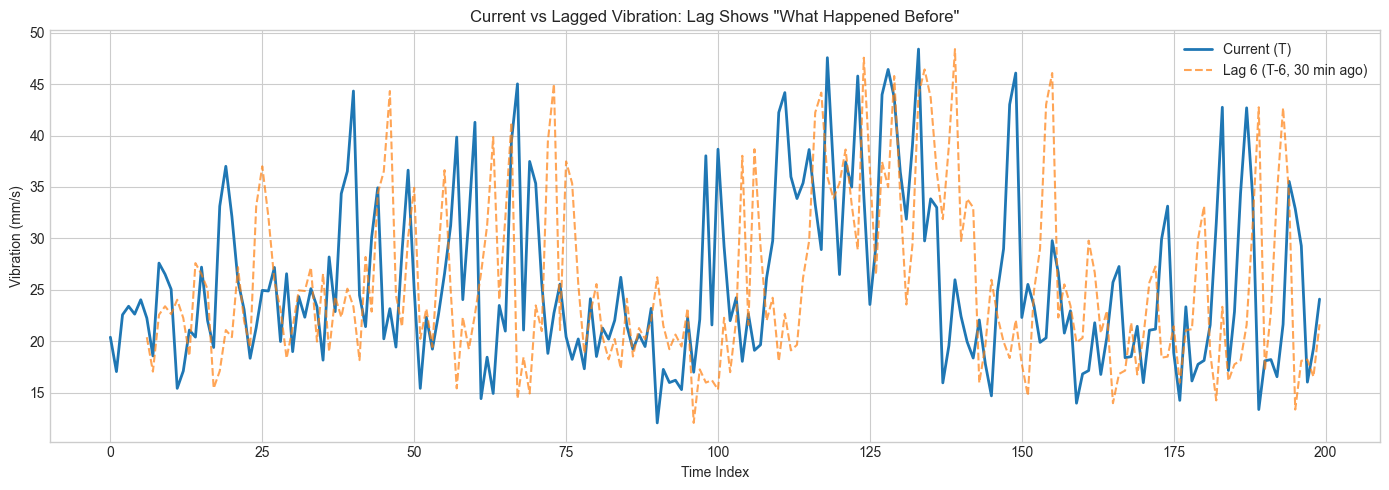

In [14]:
# Visualize: Current vs Lagged values
fig, ax = plt.subplots(figsize=(14, 5))

n = 200
x = range(n)
ax.plot(x, m1_lags['vibration_mm_s'].iloc[:n], label='Current (T)', linewidth=2)
ax.plot(x, m1_lags['vibration_lag_6'].iloc[:n], label='Lag 6 (T-6, 30 min ago)', 
        alpha=0.7, linestyle='--')

ax.set_xlabel('Time Index')
ax.set_ylabel('Vibration (mm/s)')
ax.set_title('Current vs Lagged Vibration: Lag Shows "What Happened Before"')
ax.legend()
plt.tight_layout()
plt.show()

### Lag Features We Create:

For 7 key columns, we create lags at T-1, T-2, T-6:
- `vibration_mm_s`, `pressure_psi`, `torque_Nm`, `rotational_speed_rpm`
- `error_rate_pct`, `cpu_utilization_pct`, `network_latency_ms`

**Total: 7 columns × 3 lags = 21 lag features**

## 3. Cross-Domain Features

### What are Cross-Domain Features?

These combine signals from **different domains** (hardware + software) to capture complex patterns:

| Feature | Formula | What It Captures |
|---------|---------|------------------|
| `thermal_efficiency_idx` | (process_temp - air_temp) / power | Heat generated per unit power |
| `power_anomaly_score` | torque × speed / baseline | Deviation from normal power |
| `tool_wear_rate` | tool_wear / time_in_operation | How fast the tool is wearing |
| `error_under_stress` | error_rate_pct × cpu_utilization_pct | Errors when system is stressed |

In [15]:
# Load the merged data (system + app logs)
sys_df = pd.read_parquet('../data/parquet/system_metrics.parquet')
app_df = pd.read_parquet('../data/parquet/application_logs.parquet')

# Merge on timestamp + machine_id
merged = pd.merge(sys_df, app_df, on=['timestamp', 'machine_id'], how='left')
print(f"Merged shape: {merged.shape}")
merged.head()

Merged shape: (50000, 32)


,timestamp,machine_id,product_type,air_temperature_K,process_temperature_K,rotational_speed_rpm,torque_Nm,tool_wear_min,vibration_mm_s,pressure_psi,...,http_5xx_count,request_throughput_rps,queue_depth,cpu_utilization_pct,memory_utilization_pct,packet_loss_pct,disk_io_wait_ms,anomaly_score,is_anomaly,maintenance_status_y
0,2024-01-01 00:00:00,M1,L,300.42,309.79,1441.0,54.48,2.6,20.395,112.96,...,4,182.89,5,48.72,37.03,0.1545,4.216,0.0132,0,Normal
1,2024-01-01 00:05:00,M2,H,301.31,311.26,1424.7,47.85,2.6,19.789,106.46,...,4,185.86,4,52.46,41.09,0.1173,2.519,0.0129,0,Normal
2,2024-01-01 00:10:00,M3,M,300.04,310.73,1640.6,49.78,1.0,17.637,109.73,...,5,210.72,4,45.15,35.25,0.3482,1.911,0.0142,0,Normal
3,2024-01-01 00:15:00,M4,L,299.03,308.53,1263.7,56.08,2.3,14.856,110.42,...,2,162.90,5,34.99,37.33,0.1378,3.867,0.0204,0,Normal
4,2024-01-01 00:20:00,M5,L,300.89,309.48,1394.3,51.25,1.5,19.512,112.86,...,1,202.38,4,36.45,35.71,0.2211,3.201,0.0153,0,Normal


In [16]:
# Create cross-domain features
def create_cross_domain_features(df):
    """Create features that combine hardware and software signals."""
    df = df.copy()
    
    # 1. Thermal Efficiency Index
    # High value = generating too much heat for the power used
    temp_diff = df['process_temperature_K'] - df['air_temperature_K']
    power = (df['torque_Nm'] * df['rotational_speed_rpm']) / 9550  # kW
    df['thermal_efficiency_idx'] = temp_diff / (power + 0.1)  # avoid div by 0
    
    # 2. Power Anomaly Score
    # Deviation from expected power consumption
    expected_power = power.rolling(36).mean()  # baseline
    df['power_anomaly_score'] = (power - expected_power).abs() / (expected_power + 0.1)
    
    # 3. Error Under Stress
    # High errors when CPU is stressed = bad sign
    df['error_under_stress'] = df['error_rate_pct'] * df['cpu_utilization_pct'] / 100
    
    # 4. Tool Wear Rate (simplified)
    df['tool_wear_rate'] = df['tool_wear_min'].diff() / 5  # change per 5-min interval
    
    return df

# Apply to one machine
m1_merged = merged[merged['machine_id'] == 'M1'].sort_values('timestamp').copy()
m1_features = create_cross_domain_features(m1_merged)

print("New cross-domain features:")
print(m1_features[['thermal_efficiency_idx', 'power_anomaly_score', 
                   'error_under_stress', 'tool_wear_rate']].describe())

New cross-domain features:
       thermal_efficiency_idx  power_anomaly_score  error_under_stress  \
count            10000.000000          9965.000000        10000.000000   
mean                 1.335412             0.097952            4.710619   
std                  0.216447             0.081091            5.332327   
min                  0.738300             0.000020            0.124272   
25%                  1.192458             0.037248            0.919218   
50%                  1.312977             0.077705            1.746343   
75%                  1.449419             0.138184            7.569637   
max                  3.261861             0.659855           27.664956   

       tool_wear_rate  
count     9999.000000  
mean         0.001790  
std          4.273528  
min        -50.000000  
25%          0.240000  
50%          0.360000  
75%          0.500000  
max          0.900000  


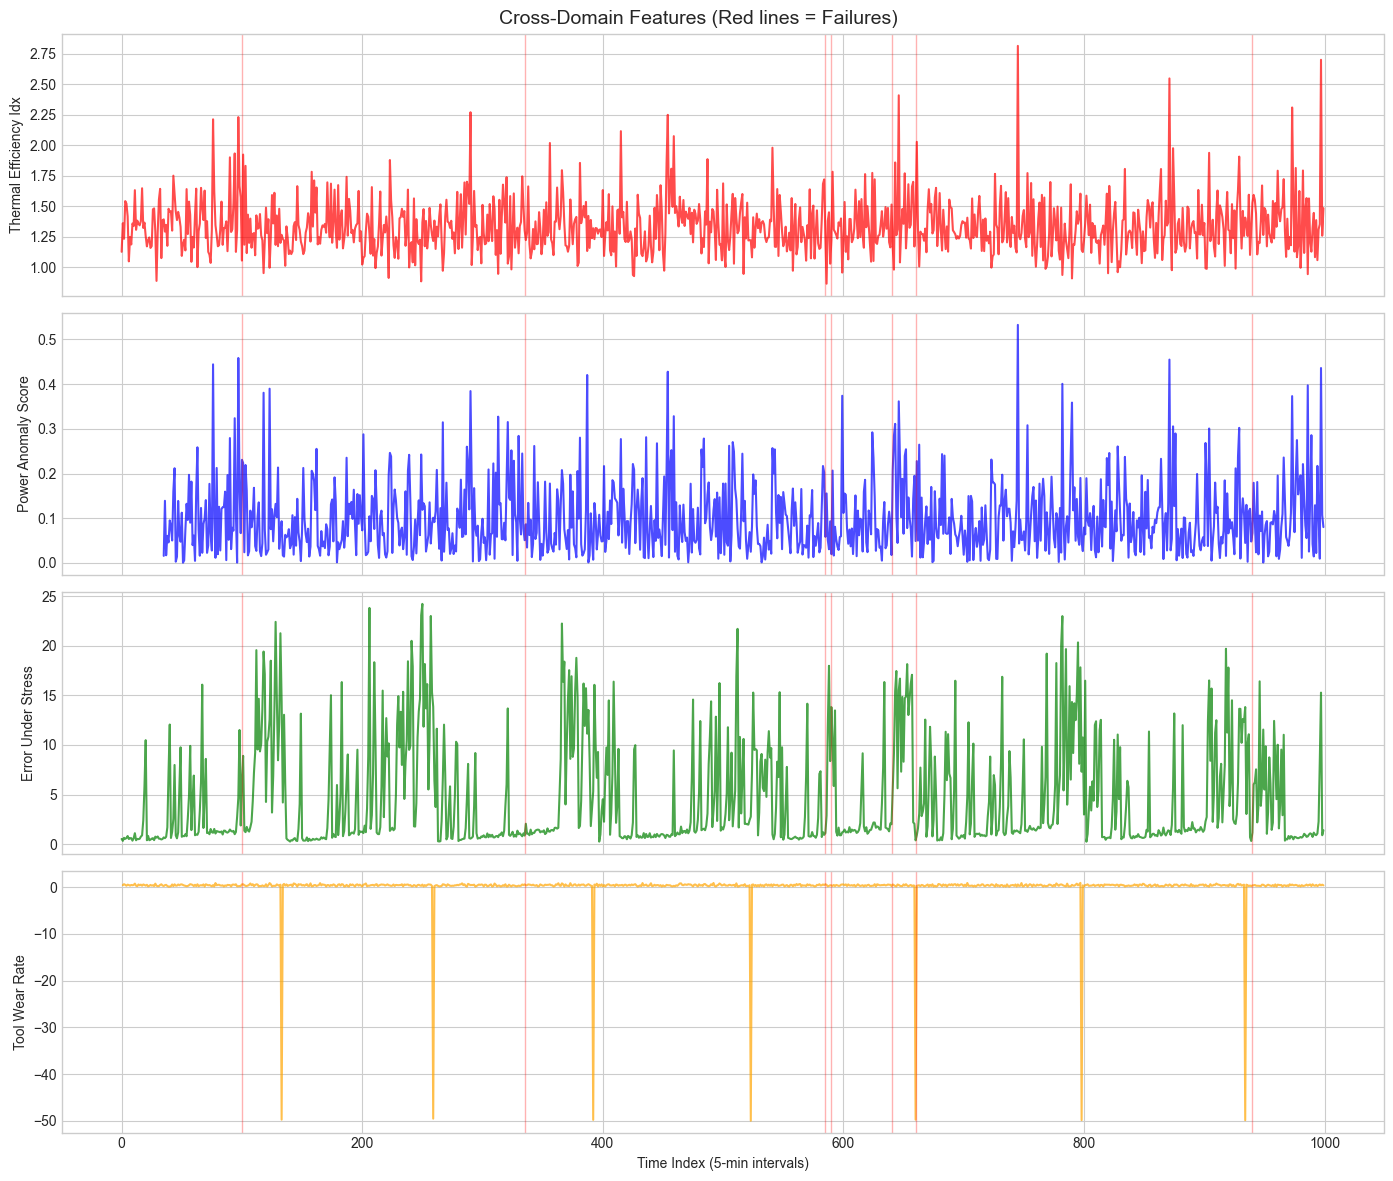

In [17]:
# Visualize cross-domain features during failures
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

n = 1000
x = range(n)

# Plot each cross-domain feature
features = ['thermal_efficiency_idx', 'power_anomaly_score', 
            'error_under_stress', 'tool_wear_rate']
colors = ['red', 'blue', 'green', 'orange']

for i, (feat, color) in enumerate(zip(features, colors)):
    axes[i].plot(x, m1_features[feat].iloc[:n], color=color, alpha=0.7)
    axes[i].set_ylabel(feat.replace('_', ' ').title())
    
    # Mark failures
    failures = m1_features[m1_features['machine_failure'] == 1].index[:n]
    failures = [f for f in failures if f < n]
    for f in failures:
        axes[i].axvline(x=f, color='red', alpha=0.3, linewidth=1)

axes[3].set_xlabel('Time Index (5-min intervals)')
plt.suptitle('Cross-Domain Features (Red lines = Failures)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. The NaN Problem (Warm-up Period)

### Why Do We Get NaN Values?

Rolling windows and lags need **historical data** to compute:
- `rolling(36).mean()` needs 36 prior rows
- `shift(6)` needs 6 prior rows

At the start of each machine's data, these don't exist → **NaN**

```
Row 1: Rolling_36_mean = NaN (only 1 row available)
Row 2: Rolling_36_mean = NaN (only 2 rows available)
...
Row 36: Rolling_36_mean = first valid value!
```

In [18]:
# Demonstrate warm-up NaN
demo = m1[['timestamp', 'vibration_mm_s']].head(40).copy()
demo['rolling_6_mean'] = demo['vibration_mm_s'].rolling(6).mean()
demo['rolling_36_mean'] = demo['vibration_mm_s'].rolling(36).mean()
demo['lag_6'] = demo['vibration_mm_s'].shift(6)

print("Warm-up period NaN demonstration:")
demo.head(40)

Warm-up period NaN demonstration:


,timestamp,vibration_mm_s,rolling_6_mean,rolling_36_mean,lag_6
0,2024-01-01 00:00:00,20.395,NaN,NaN,NaN
1,2024-01-01 00:25:00,17.054,NaN,NaN,NaN
2,2024-01-01 00:50:00,22.576,NaN,NaN,NaN
3,2024-01-01 01:15:00,23.404,NaN,NaN,NaN
4,2024-01-01 01:40:00,22.640,NaN,NaN,NaN
5,2024-01-01 02:05:00,24.036,21.684167,NaN,NaN
6,2024-01-01 02:30:00,22.254,21.994000,NaN,20.395
7,2024-01-01 02:55:00,18.578,22.248000,NaN,17.054
8,2024-01-01 03:20:00,27.597,23.084833,NaN,22.576
9,2024-01-01 03:45:00,26.516,23.603500,NaN,23.404


In [19]:
# Count NaN per feature
nan_counts = demo[['rolling_6_mean', 'rolling_36_mean', 'lag_6']].isna().sum()
print("NaN count per feature:")
print(nan_counts)
print(f"\nMax warm-up period: {nan_counts.max()} rows")

NaN count per feature:
rolling_6_mean      5
rolling_36_mean    35
lag_6               6
dtype: int64

Max warm-up period: 35 rows


### Our Solution: Fill NaN with 0

We fill these warm-up NaN with 0 because:
- "No prior data" semantically means "no signal" or "no change"
- Only ~0.007% of total cells are NaN (30 rows × 5 machines = 150 cells out of millions)
- Better than dropping rows (would lose healthy baseline data)

## 5. The Chunk Boundary Problem

When processing in chunks (for memory efficiency), there's a problem:

```
Chunk 1: [row 0 ... row 4999]   ← rolling window works fine
Chunk 2: [row 5000 ... row 9999] ← row 5000 has NO history!
                                    rolling_36_mean = NaN (can't see chunk 1)
```

### Solution: Lookback Buffer

We keep the **last 36 rows of each machine** from chunk N, and prepend them to chunk N+1:

```
Chunk 1: [row 0 ... row 4999]
    → Store buffer: [row 4964 ... row 4999] (last 36 rows)

Chunk 2: [buffer] + [row 5000 ... row 9999]
    → Row 5000 now has 36 rows of history!
    → After computing features, strip buffer from output
```

In [20]:
# Demonstrate buffer solution
def process_with_buffer(data, chunk_size=100, buffer_size=36):
    """Process data in chunks with lookback buffer."""
    results = []
    buffer = pd.DataFrame()  # Empty at start
    
    n_chunks = (len(data) + chunk_size - 1) // chunk_size
    
    for i in range(n_chunks):
        start = i * chunk_size
        end = min(start + chunk_size, len(data))
        chunk = data.iloc[start:end].copy()
        
        # Prepend buffer
        if not buffer.empty:
            buffer['_is_buffer'] = True
            chunk['_is_buffer'] = False
            augmented = pd.concat([buffer, chunk], ignore_index=True)
        else:
            chunk['_is_buffer'] = False
            augmented = chunk
        
        # Compute rolling feature
        augmented['rolling_36_mean'] = augmented['vibration_mm_s'].rolling(36).mean()
        
        # Strip buffer rows from result
        result = augmented[~augmented['_is_buffer']].drop(columns=['_is_buffer'])
        results.append(result)
        
        # Update buffer for next chunk
        buffer = chunk.tail(buffer_size).drop(columns=['_is_buffer'], errors='ignore').copy()
        
        # Count NaN in this chunk
        nan_count = result['rolling_36_mean'].isna().sum()
        print(f"Chunk {i+1}: {len(result)} rows, NaN = {nan_count}")
    
    return pd.concat(results, ignore_index=True)

# Test on sample data
sample = m1[['timestamp', 'vibration_mm_s']].head(500).copy()
print("Processing with lookback buffer:")
result = process_with_buffer(sample, chunk_size=100, buffer_size=36)

Processing with lookback buffer:
Chunk 1: 100 rows, NaN = 35
Chunk 2: 100 rows, NaN = 0
Chunk 3: 100 rows, NaN = 0
Chunk 4: 100 rows, NaN = 0
Chunk 5: 100 rows, NaN = 0


In [21]:
# Verify: NaN only at the very start (first 35 rows total)
total_nan = result['rolling_36_mean'].isna().sum()
print(f"\nTotal NaN in result: {total_nan}")
print(f"Expected NaN (warm-up only): 35")
print(f"Buffer working correctly: {total_nan == 35}")


Total NaN in result: 35
Expected NaN (warm-up only): 35
Buffer working correctly: True


## 6. Final Feature Matrix

Let's look at what our feature engineering pipeline produces:

In [22]:
# Load the actual feature matrix (output from feature_engineer.py)
feature_matrix = pd.read_parquet('../data/features/feature_matrix.parquet')

print("=== Final Feature Matrix ===")
print(f"Shape: {feature_matrix.shape[0]:,} rows × {feature_matrix.shape[1]} columns")
print(f"\nMemory usage: {feature_matrix.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

=== Final Feature Matrix ===
Shape: 50,000 rows × 137 columns

Memory usage: 58.1 MB


In [23]:
# Feature categories
cols = feature_matrix.columns.tolist()

rolling_mean = [c for c in cols if '_mean_' in c]
rolling_std = [c for c in cols if '_std_' in c]
lag_features = [c for c in cols if '_lag_' in c]
cross_domain = ['thermal_efficiency_idx', 'power_anomaly_score', 
                'tool_wear_rate', 'error_under_stress']
cross_domain = [c for c in cross_domain if c in cols]

print("Feature Breakdown:")
print(f"  Rolling Mean features: {len(rolling_mean)}")
print(f"  Rolling Std features:  {len(rolling_std)}")
print(f"  Lag features:          {len(lag_features)}")
print(f"  Cross-domain features: {len(cross_domain)}")
print(f"  Original columns:      {len(cols) - len(rolling_mean) - len(rolling_std) - len(lag_features) - len(cross_domain)}")
print(f"  ─────────────────────────")
print(f"  Total:                 {len(cols)}")

Feature Breakdown:
  Rolling Mean features: 39
  Rolling Std features:  39
  Lag features:          21
  Cross-domain features: 4
  Original columns:      34
  ─────────────────────────
  Total:                 137


In [24]:
# Check NaN density
nan_count = feature_matrix.isna().sum().sum()
total_cells = feature_matrix.shape[0] * feature_matrix.shape[1]
nan_pct = nan_count / total_cells * 100

print(f"NaN Analysis:")
print(f"  Total NaN cells: {nan_count:,}")
print(f"  Total cells:     {total_cells:,}")
print(f"  NaN percentage:  {nan_pct:.4f}%")

NaN Analysis:
  Total NaN cells: 515
  Total cells:     6,850,000
  NaN percentage:  0.0075%


In [25]:
# Sample of feature names
print("Sample Feature Names:")
print("\nRolling Mean (first 5):")
for f in rolling_mean[:5]:
    print(f"  {f}")

print("\nLag Features (first 5):")
for f in lag_features[:5]:
    print(f"  {f}")

print("\nCross-Domain:")
for f in cross_domain:
    print(f"  {f}")

Sample Feature Names:

Rolling Mean (first 5):
  air_temperature_K_mean_6
  air_temperature_K_mean_12
  air_temperature_K_mean_36
  process_temperature_K_mean_6
  process_temperature_K_mean_12

Lag Features (first 5):
  torque_Nm_lag_1
  torque_Nm_lag_2
  torque_Nm_lag_6
  vibration_mm_s_lag_1
  vibration_mm_s_lag_2

Cross-Domain:
  thermal_efficiency_idx
  power_anomaly_score
  tool_wear_rate
  error_under_stress


## 7. Summary

### Stage 2 Accomplishes:

| Feature Type | Count | Purpose |
|--------------|-------|--------|
| Rolling Mean | 39 | Smoothed trends over time |
| Rolling Std | 39 | Variability/stability |
| Lag Features | 21 | Recent history (T-1, T-2, T-6) |
| Cross-Domain | 6 | Hardware+software interactions |
| **Total** | **~136** | Full predictive feature set |

### Key Concepts:
1. **Rolling windows** capture trends and variability
2. **Lag features** capture recent history
3. **Cross-domain features** combine signals from different sources
4. **Lookback buffer** ensures continuity at chunk boundaries
5. **NaN handling**: Only warm-up NaN (0.007%), filled with 0

### Next: Model Training (Notebook 4)
We now have 136 features ready for XGBoost training!